Clarification: Discuss ideas and some method usage with Hua Tu. Code debug with google gemini.

In [78]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
csv_path = '/content/drive/My Drive/MSSP607/Assignments/data_academic_performance.csv'
df = pd.read_csv(csv_path)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,COD_S11,GENDER,EDU_FATHER,EDU_MOTHER,OCC_FATHER,OCC_MOTHER,STRATUM,SISBEN,PEOPLE_HOUSE,Unnamed: 9,...,CC_PRO,ENG_PRO,WC_PRO,FEP_PRO,G_SC,PERCENTILE,2ND_DECILE,QUARTILE,SEL,SEL_IHE
0,SB11201210000129,F,Incomplete Professional Education,Complete technique or technology,Technical or professional level employee,Home,Stratum 4,It is not classified by the SISBEN,Three,NaN,...,71,93,79,181,180,91,5,4,2,2
1,SB11201210000137,F,Complete Secundary,Complete professional education,Entrepreneur,Independent professional,Stratum 5,It is not classified by the SISBEN,Three,NaN,...,86,98,78,201,182,92,5,4,4,4
2,SB11201210005154,M,Not sure,Not sure,Independent,Home,Stratum 2,Level 2,Five,NaN,...,18,43,22,113,113,7,1,1,1,1
3,SB11201210007504,F,Not sure,Not sure,Other occupation,Independent,Stratum 2,It is not classified by the SISBEN,Three,NaN,...,76,80,48,137,157,67,4,3,2,2
4,SB11201210007548,M,Complete professional education,Complete professional education,Executive,Home,Stratum 4,It is not classified by the SISBEN,One,NaN,...,98,100,71,189,198,98,5,4,4,2


In [93]:
#Clean the parent education columns into 5 groups
edu_groups = {
    "Ninguno": "1 Primary or less",
    "Incomplete Primary": "1 Primary or less", "Complete Primary": "1 Primary or less",
    "Incomplete Secondary": "2 Secondary", "Complete Secondary": "2 Secondary",
    "Incomplete technical or technological": "3 Technical", "Complete technique or technology": "3 Technical",
    "Incomplete professional education":"4 University", "Complete professional education":"4 University",
    "Postgraduate education":"5 Post-graduate"}
df["MOTHER_EDU"] = df["EDU_MOTHER"].map(edu_groups)
df["FATHER_EDU"] = df["EDU_FATHER"].map(edu_groups)

for col in ["EDU_FATHER", "EDU_MOTHER"]:
    df[col]=df[col].replace({0:np.nan, "0": np.nan})

In [108]:
#High school average
s11 = ["MAT_S11", "CR_S11", "CC_S11", "BIO_S11", "ENG_S11"]
df["S11_AVG"] = df[s11].mean(axis=1)

In [54]:
# summarize the numerical attributes by catergories
scores = ["MAT_S11","CR_S11","CC_S11","BIO_S11","ENG_S11","QR_PRO","CR_PRO","CC_PRO","ENG_PRO","WC_PRO","G_SC"]
df[scores].agg(["mean", "median", "std", "min", "max"]).round(1).T


,mean,median,std,min,max
MAT_S11,64.3,64.0,11.9,26.0,100.0
CR_S11,60.8,61.0,10.0,24.0,100.0
CC_S11,60.7,60.0,10.1,0.0,100.0
BIO_S11,64.0,64.0,11.2,11.0,100.0
ENG_S11,61.8,59.0,14.3,26.0,100.0
QR_PRO,77.4,85.0,22.7,1.0,100.0
CR_PRO,62.2,67.0,27.7,1.0,100.0
CC_PRO,59.2,65.0,29.0,1.0,100.0
ENG_PRO,67.5,74.0,25.5,1.0,100.0
WC_PRO,53.7,56.0,30.0,0.0,100.0


In [55]:
#Test by gender
print(df.groupby("GENDER")[scores].agg(["mean", "median", "std", "min", "max"]).round(1).T)

GENDER              F      M
MAT_S11 mean     61.9   66.0
        median   61.0   65.0
        std      11.2   12.1
        min      31.0   26.0
        max     100.0  100.0
CR_S11  mean     60.9   60.7
        median   61.0   61.0
        std       9.9   10.1
        min      28.0   24.0
        max     100.0  100.0
CC_S11  mean     60.0   61.2
        median   60.0   61.0
        std       9.5   10.5
        min      29.0    0.0
        max     100.0  100.0
BIO_S11 mean     62.3   65.1
        median   62.0   65.0
        std      10.5   11.4
        min      11.0   20.0
        max     100.0  100.0
ENG_S11 mean     61.5   62.0
        median   59.0   59.0
        std      13.8   14.6
        min      26.0   30.0
        max     100.0  100.0
QR_PRO  mean     71.9   81.2
        median   78.0   89.0
        std      24.1   20.8
        min       1.0    1.0
        max     100.0  100.0
CR_PRO  mean     61.3   62.8
        median   66.0   69.0
        std      27.3   27.9
        min   

In [56]:
#Mean of every test by gender
gender_means = df.groupby("GENDER")[scores].mean().round(1).T
gender_means["M - F"] = (gender_means["M"] - gender_means["F"]).round(1)
gender_means

GENDER,F,M,M - F
MAT_S11,61.9,66.0,4.1
CR_S11,60.9,60.7,-0.2
CC_S11,60.0,61.2,1.2
BIO_S11,62.3,65.1,2.8
ENG_S11,61.5,62.0,0.5
QR_PRO,71.9,81.2,9.3
CR_PRO,61.3,62.8,1.5
CC_PRO,58.6,59.6,1.0
ENG_PRO,66.5,68.2,1.7
WC_PRO,56.6,51.7,-4.9


Text(0.5, 1.0, 'Gender differences by courses (blue = male higher, red = female higher)')

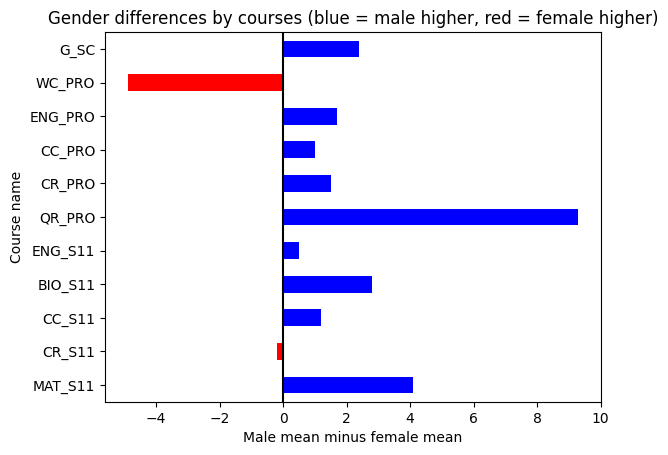

In [94]:
#Create bar chart for gender difference
gender_diff = gender_means["M - F"]
gender_diff.plot(kind ="barh", color = ["red" if x < 0 else "blue" for x in gender_diff])
plt.axvline(0, color= "black")
plt.xlabel("Male mean minus female mean")
plt.ylabel("Course name")
plt.title("Gender differences by courses (blue = male higher, red = female higher)")

In [101]:
#Stratum
stratum_table = df.groupby("STRATUM")["G_SC"].agg(["count","mean", "median", "std", "min", "max"]).round(1)
stratum_table

,count,mean,median,std,min,max
STRATUM,,,,,,
0,14,154.0,152.5,21.3,116,196
Stratum 1,1709,152.4,152.0,21.9,77,220
Stratum 2,4029,158.2,158.0,22.3,72,237
Stratum 3,4045,163.8,164.0,21.7,75,247
Stratum 4,1578,172.0,174.0,21.5,91,243
Stratum 5,633,177.4,179.0,21.5,37,246
Stratum 6,403,181.5,184.0,21.9,91,242


Text(0.5, 1.0, 'Mean global score by stratum')

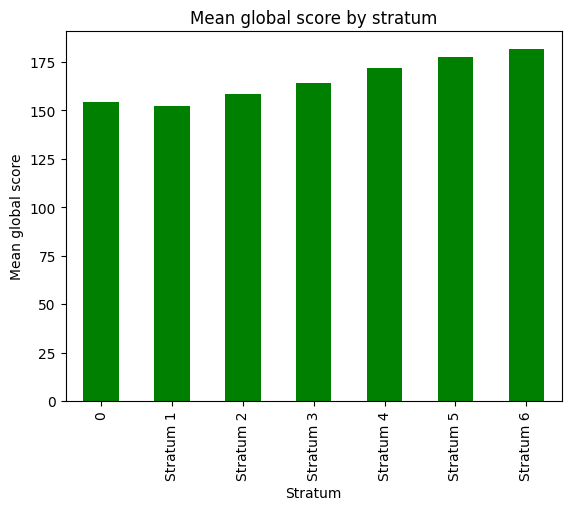

In [102]:
df.groupby("STRATUM")["G_SC"].mean().plot(kind="bar", color="green")
plt.xlabel("Stratum")
plt.ylabel("Mean global score")
plt.title("Mean global score by stratum")

In [106]:
#t-test between the two extreme groups
s1 = df[df.STRATUM == "Stratum 1"]["G_SC"]
s6 = df[df.STRATUM == "Stratum 6"]["G_SC"]
t,p = stats.ttest_ind(s1, s6, equal_var = False)
print(f"Stratum 1 mean = {s1.mean():.1f}, Stratum 6 mean = {s2.mean():.1f}, difference = {s6.mean()-s1.mean():.1f}, t = {t:.2f}, p = {p:.4f}")

Stratum 1 mean = 152.4, Stratum 6 mean = 181.5, difference = 29.2, t = -24.05, p = 0.0000


In [95]:
#Parent education with Global Score
mother_edu_table = df.groupby("MOTHER_EDU")["G_SC"].agg(["count","mean", "median", "std", "min", "max"]).round(1)
father_edu_table = df.groupby("FATHER_EDU")["G_SC"].agg(["count","mean", "median", "std", "min", "max"]).round(1)
print(mother_edu_table)
print(father_edu_table)
mother_edu = df.groupby("MOTHER_EDU")["G_SC"].mean().round(1).T
father_edu = df.groupby("FATHER_EDU")["G_SC"].mean().round(1).T
print(mother_edu)
print(father_edu)

                   count   mean  median   std  min  max
MOTHER_EDU                                             
1 Primary or less     34  149.7   152.5  27.9   77  220
3 Technical         1836  163.0   163.0  21.7   91  234
4 University        3059  168.8   170.0  23.0   91  246
5 Post-graduate      997  175.6   178.0  22.1  100  242
                   count   mean  median   std  min  max
FATHER_EDU                                             
1 Primary or less    123  156.6   159.0  23.2   77  220
3 Technical         1471  163.7   164.0  22.1   75  228
4 University        3016  167.8   169.0  23.0   76  247
5 Post-graduate     1085  177.0   179.0  21.7  110  242
MOTHER_EDU
1 Primary or less    149.7
3 Technical          163.0
4 University         168.8
5 Post-graduate      175.6
Name: G_SC, dtype: float64
FATHER_EDU
1 Primary or less    156.6
3 Technical          163.7
4 University         167.8
5 Post-graduate      177.0
Name: G_SC, dtype: float64


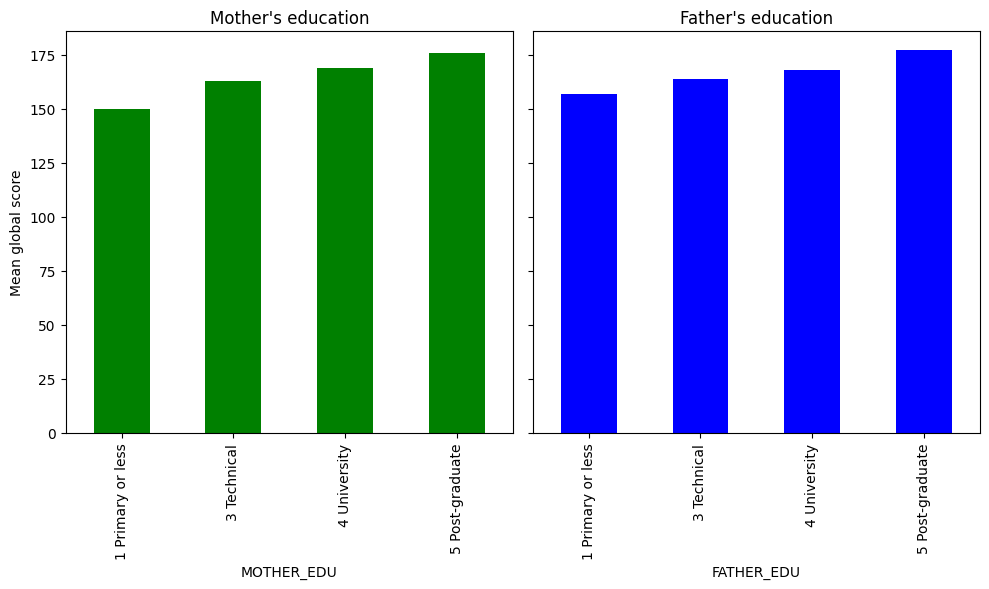

In [74]:
#Create bar plot
fig, ax = plt.subplots(1,2, figsize=(10,6), sharey = True)
df.groupby("MOTHER_EDU")["G_SC"].mean().plot(kind="bar", ax=ax[0], color="green"); ax[0].set_title("Mother's education")
df.groupby("FATHER_EDU")["G_SC"].mean().plot(kind="bar", ax=ax[1], color="blue"); ax[1].set_title("Father's education")
for a in ax: a.set_ylabel("Mean global score"),plt.tight_layout()

In [100]:
#Compare the gap between parent education
high = df[df.MOTHER_EDU == "5 Post-graduate"]["G_SC"]
low = df[df.MOTHER_EDU == "3 Technical"]["G_SC"]
t,p = stats.ttest_ind(high, low, equal_var = False)
print(f"Postgraduate mean = {high.mean():.1f}, Technical mean = {low.mean():.1f}")
print(f"Difference = {high.mean()-low.mean():.1f} points ({(high.mean()-low.mean())/low.mean()*100:.1f}% higher), t = {t:.2f}, p = {p:.4f}")
print(f"(For reference, the standard deviation of G_SC is {df.G_SC.std():.1f})")

Postgraduate mean = 175.6, Technical mean = 163.0
Difference = 12.6 points (7.8% higher), t = 14.63, p = 0.0000
(For reference, the standard deviation of G_SC is 23.1)


In [109]:
#High school score vs. professional education score
provs11 = df.groupby("STRATUM")[["S11_AVG", "QR_PRO", "ENG_PRO", "G_SC"]].mean().round(1)
provs11["gap_vs_Stratum_1_S11"] = provs11["S11_AVG"] - provs11.loc["Stratum 1"]["S11_AVG"].round(1)
provs11

,S11_AVG,QR_PRO,ENG_PRO,G_SC,gap_vs_Stratum_1_S11
STRATUM,,,,,
0,54.9,69.8,55.1,154.0,-2.7
Stratum 1,57.6,70.5,50.9,152.4,0.0
Stratum 2,59.9,74.6,60.9,158.2,2.3
Stratum 3,62.7,78.3,70.6,163.8,5.1
Stratum 4,66.9,83.2,80.1,172.0,9.3
Stratum 5,70.1,86.7,87.0,177.4,12.5
Stratum 6,72.5,88.4,92.5,181.5,14.9


        S11_AVG   G_SC
GENDER                
F          61.3  161.3
M          63.0  163.7
Correlation S11_AVG vs G_SC: 0.78


Text(0.5, 1.0, 'Correlation between high school average and final global score')

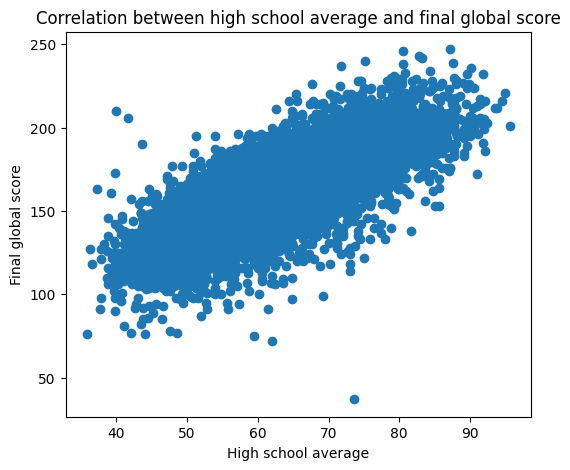

In [112]:
#high school average vs final global score by gender
print(df.groupby("GENDER")[["S11_AVG", "G_SC"]].mean().round(1))
#Correlation between high school average vs final global score
print("Correlation S11_AVG vs G_SC:", round(df["S11_AVG"].corr(df["G_SC"]),2))
plt.figure(figsize = (6,5)); plt.scatter(df["S11_AVG"], df["G_SC"])
plt.xlabel("High school average"); plt.ylabel("Final global score")
plt.title("Correlation between high school average and final global score")